# Encoding analysis: wilbur20210512

**Contents**

1. [Setup](#Setup)
2. [Single-variable models](#Single-variable-models)
   - Null · Trial type · Choice · Speed · Position · Trial progress
3. [Combined models](#Combined-models)
   - Full · Temporal · Choice full · Choice temporal
4. [Model comparison](#Model-comparison)
   - Single-variable AIC/LRT · Drop-one & LRT
5. [Visualization](#Visualization)
   - Place field maps


In [1]:
%run common_imports.py

%matplotlib qt
%config InlineBackend.figure_format = 'retina'
sns.set_context("talk")

%reload_ext autoreload
%autoreload 2
pd.options.display.max_rows = 600
pd.set_option('display.float_format', lambda x: '%.9f' % x)

dj.config['display.limit'] = 10**3  

os.environ["SPYGLASS_USE_TRANSACTIONS"] = "1"  
os.environ['KACHERY_API_KEY'] = "RhysjLwgmBAt2ObCyXXaDnqAv2kTdYRa"

[2026-03-15 12:37:09,433][INFO]: DataJoint is configured from /media/labuser/NA_1_2025/spyglass/wilbur/dj_local_conf.json
[2026-03-15 12:37:09,864][INFO]: DataJoint 0.14.9 connected to anirudh@172.16.102.154:3306


In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats         
from scipy.stats import chi2 
import spyglass.linearization.v1 as sgpl                                                                       

In [68]:
from notebooks.encoding_utils import (
    interp_col, fit_glm_all_units,
    make_drop_one_specs, build_reduced_formula,
    fit_drop_one, run_drop_one_suite, compute_drop_one_lrt,
    apply_fdr_correction, pairwise_term_comparison,
    plot_drop_one_summary,
    set_plot_state, plot_place_field, plot_place_field_grid,
    plot_tuning_comparison, plot_categorical_comparison,
    plot_wtrack_comparison, plot_partial_dependence_grid,
    plot_diagnostics, plot_diagnostics_batch,
    compute_model_diagnostics, compute_diagnostics_all_units,
    plot_diagnostics_population,
    compute_residual_profiles, plot_residual_profiles,
    plot_residual_heterogeneity,
)

## Setup

### Load data

In [4]:
#extract position data
#read from csv
trialized_position = pd.read_csv("/media/labuser/NA_1_2025/spyglass/wilbur/analysis/position/trialized_position.csv", index_col = "time")

In [5]:
#extract spikes
#read from npz
data = np.load("/media/labuser/NA_1_2025/spyglass/wilbur/analysis/final_spikes/mfpc_spikes.npz", allow_pickle=True)
mpfc_spikes = [data[f"arr_{i}"] for i in range(len(data.files))]


### Prepare dataframe for regression

In [6]:
BIN_SIZE = 0.002  

bin_edges = np.arange(
    trialized_position.index.min(), trialized_position.index.max() + BIN_SIZE, BIN_SIZE
)
bin_centers = bin_edges[:-1] + BIN_SIZE / 2

spike_counts = np.array([np.histogram(spikes, bins=bin_edges)[0] for spikes in mpfc_spikes]) 

In [7]:
# interp_col → encoding_utils.py

cols_to_interp = [c for c in trialized_position.columns if c != "video_frame_ind"]
times = trialized_position.index.astype(float).values

interpolated = {col: interp_col(trialized_position[col], times, bin_centers) for col in cols_to_interp}

interp_trialised_position = pd.DataFrame(interpolated, columns=cols_to_interp)
interp_trialised_position.insert(0, "time_bin_center", bin_centers)

mask = (interp_trialised_position["zone"]=="run") &\
    (interp_trialised_position["trial_type"].isin(["outbound", "inbound"]))


cov_df = interp_trialised_position[mask]
spike_counts_masked = spike_counts[:, mask]
unit_ids = np.arange(0, len(spike_counts_masked))

In [8]:
cov_df = cov_df.rename(columns={"left/right": "choice"})

In [ ]:
# Intersection of all predictor filters — all models fit on this for valid AIC comparison
common_mask = (
    cov_df["speed"].notna() & (cov_df["speed"] > 5) & (cov_df["speed"] < 120)
    & cov_df["linear_position"].notna()
)
cov_df_common = cov_df[common_mask].copy()
spike_counts_common = spike_counts_masked[:, common_mask]

# Scaling params defined once — used by all single-unit and all-units cells
speed_min_val = cov_df_common["speed"].min()
speed_max_val = cov_df_common["speed"].max()
pos_min_val   = cov_df_common["linear_position"].min()
pos_max_val   = cov_df_common["linear_position"].max()

cov_df_common["speed_scaled"] = (cov_df_common["speed"] - speed_min_val) / (speed_max_val - speed_min_val)
cov_df_common["pos_scaled"]   = (cov_df_common["linear_position"] - pos_min_val) / (pos_max_val - pos_min_val)

# Outbound-only common subset — baseline and choice model
outbound_common_mask = common_mask & (cov_df["trial_type"] == "outbound")
cov_df_out_common = cov_df[outbound_common_mask].copy()
spike_counts_out_common = spike_counts_masked[:, outbound_common_mask]
cov_df_out_common["speed_scaled"] = (cov_df_out_common["speed"] - speed_min_val) / (speed_max_val - speed_min_val)
cov_df_out_common["pos_scaled"]   = (cov_df_out_common["linear_position"] - pos_min_val) / (pos_max_val - pos_min_val)


print(f"cov_df_common: {len(cov_df_common):,} bins")
print(f"cov_df_out_common: {len(cov_df_out_common):,} bins (outbound only)")

### Models:

#### Single-variable models:
1. Null model (constant rate)
2. Null model (outbound only, for comparison with other outbound-only models)
2. spike_count ~ trial_type (categorical)
3. spike_count ~ left/right choice (categorical)
4. spike_count ~ speed (linear)
5. spike_count ~ bs(speed, df = 4) (spline)
6. spike_count ~ bs(linear_position, df = 8) (spline)
7. **spike_count ~ cr(progress, df= 6) (spline)**

#### Mutli-variable models:
1. spike_count ~ trial_type + bs(speed) + bs(linear_position) 
2. spike_count ~ trial_type + bs(speed) + cr(trial_progress)
3. spike_count ~ choice + bs(speed) + bs(linear_position)
4. spike_count ~ choice + bs(speed) + cr(trial_progress)


In [ ]:
UNIT_LIST = [12, 47, 103, 211, 58]

## Single-variable models

### Null model

#### Fit on one unit 

In [10]:
unit_idx = 9
spk_cov_df = cov_df.copy(); spk_cov_df["spike_count"] = spike_counts_masked[unit_idx]
spk_cov_df_common = cov_df_common.copy(); spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]
choice_spk_cov_df = spk_cov_df[cov_df["trial_type"] == "outbound"].copy()

model_constant = smf.glm("spike_count ~ 1", data=spk_cov_df_common, family=sm.families.Poisson())
results_constant = model_constant.fit()

print(results_constant.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:              1756595
Model:                            GLM   Df Residuals:                  1756594
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13005.
Date:                Sun, 15 Mar 2026   Deviance:                       22751.
Time:                        12:42:41   Pearson chi2:                 1.75e+06
No. Iterations:                     8   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.9832      0.025   -281.847      0.0

In [11]:
# Interpret the coefficient
mean_count_per_bin = np.exp(results_constant.params["Intercept"])
mean_rate_hz = mean_count_per_bin / BIN_SIZE

print(f"β₀ = {results_constant.params['Intercept']:.4f}")
print(f"exp(β₀) = {mean_count_per_bin:.4f} spikes/bin")
print(f"Firing rate = {mean_rate_hz:.2f} Hz")
print(f"Observed mean = {spk_cov_df['spike_count'].mean():.4f} spikes/bin")

β₀ = -6.9832
exp(β₀) = 0.0009 spikes/bin
Firing rate = 0.46 Hz
Observed mean = 0.0011 spikes/bin


In [56]:
# Diagnostics
plot_diagnostics(results = results_constant,
                 spike_counts=spike_counts_common[unit_idx],
                 cov_df = cov_df_common,
                 unit_label = str(unit_idx),
                 show_cumulative = True,
                 panels = {})

In [57]:
formula = "spike_count ~ 1"

plot_diagnostics_batch(
    unit_list           = [12, 47, 103],  
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
)

#### Fit on all units

In [13]:
# null_model_all = fit_glm_all_units("spike_count ~ 1", cov_df_common, spike_counts_common, unit_ids)

In [14]:
# null_model_all["model"] = "null"
# null_model_all.to_csv(f"{base_dir}/analysis/null_model_all.csv")
# keep_default_na=False prevents pandas reading "null" string as NaN
null_model_all = pd.read_csv(f"{base_dir}/analysis/null_model_all.csv", index_col=0,
                              keep_default_na=False, na_values=[''])
null_model_all["model"] = "null"  # re-assign after load in case CSV was saved without it

In [15]:
null_model_all.head()

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,131669.088283882,-65833.544141941,110082.814171104,1.000000000,1756595.000000000,True,{'Intercept': -5.091031019650929},{'Intercept': 0.009619832681734403},110082.814171105,0.000000000,NaN,null
1,1,54608.689862473,-27303.344931237,46950.848745557,1.000000000,1756595.000000000,True,{'Intercept': -6.128267751876933},{'Intercept': 0.016158483907170833},46950.848745556,0.000000000,NaN,null
2,2,26819.161855586,-13408.580927793,23443.161855586,1.000000000,1756595.000000000,True,{'Intercept': -6.948180751506729},{'Intercept': 0.02434681186839675},23443.161855586,0.000000000,NaN,null
3,3,79524.794415936,-39761.397207968,67641.725887742,1.000000000,1756595.000000000,True,{'Intercept': -5.688750247654707},{'Intercept': 0.012970615923499273},67641.725887742,0.000000000,NaN,null
4,4,110086.859673762,-55042.429836881,92622.859673762,1.000000000,1756595.000000000,True,{'Intercept': -5.304252644242502},{'Intercept': 0.010702075387134087},92622.859673762,0.000000000,NaN,null


In [64]:
COVARIATE_COLS = ["linear_position", "speed"]

diag_full_null, prof_null = compute_model_diagnostics(
    formula             = "spike_count ~ 1",
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
    covariate_cols      = COVARIATE_COLS,
    base_dir            = base_dir,
    model_name          = "null_model_all",
)

Loading existing: /media/labuser/NA_1_2025/spyglass/wilbur//analysis/diagnostics_null_model_all.csv


In [65]:
diag_full_null = pd.read_csv(f"{base_dir}/analysis/diagnostics_null_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_null_model_all.npz", allow_pickle=True)
prof_null = {k: _raw[k] for k in _raw.files}

In [60]:
plot_diagnostics_population(diag_full_null,
                            covariate_cols = ["linear_position", "speed"])



/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1056: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  covariate_cols : list of covariate names; inferred from keys if None
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1065: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  
/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:1072: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes = np.atleast_1d(axes)


In [66]:
plot_residual_profiles(prof_null, covariate_cols=COVARIATE_COLS)


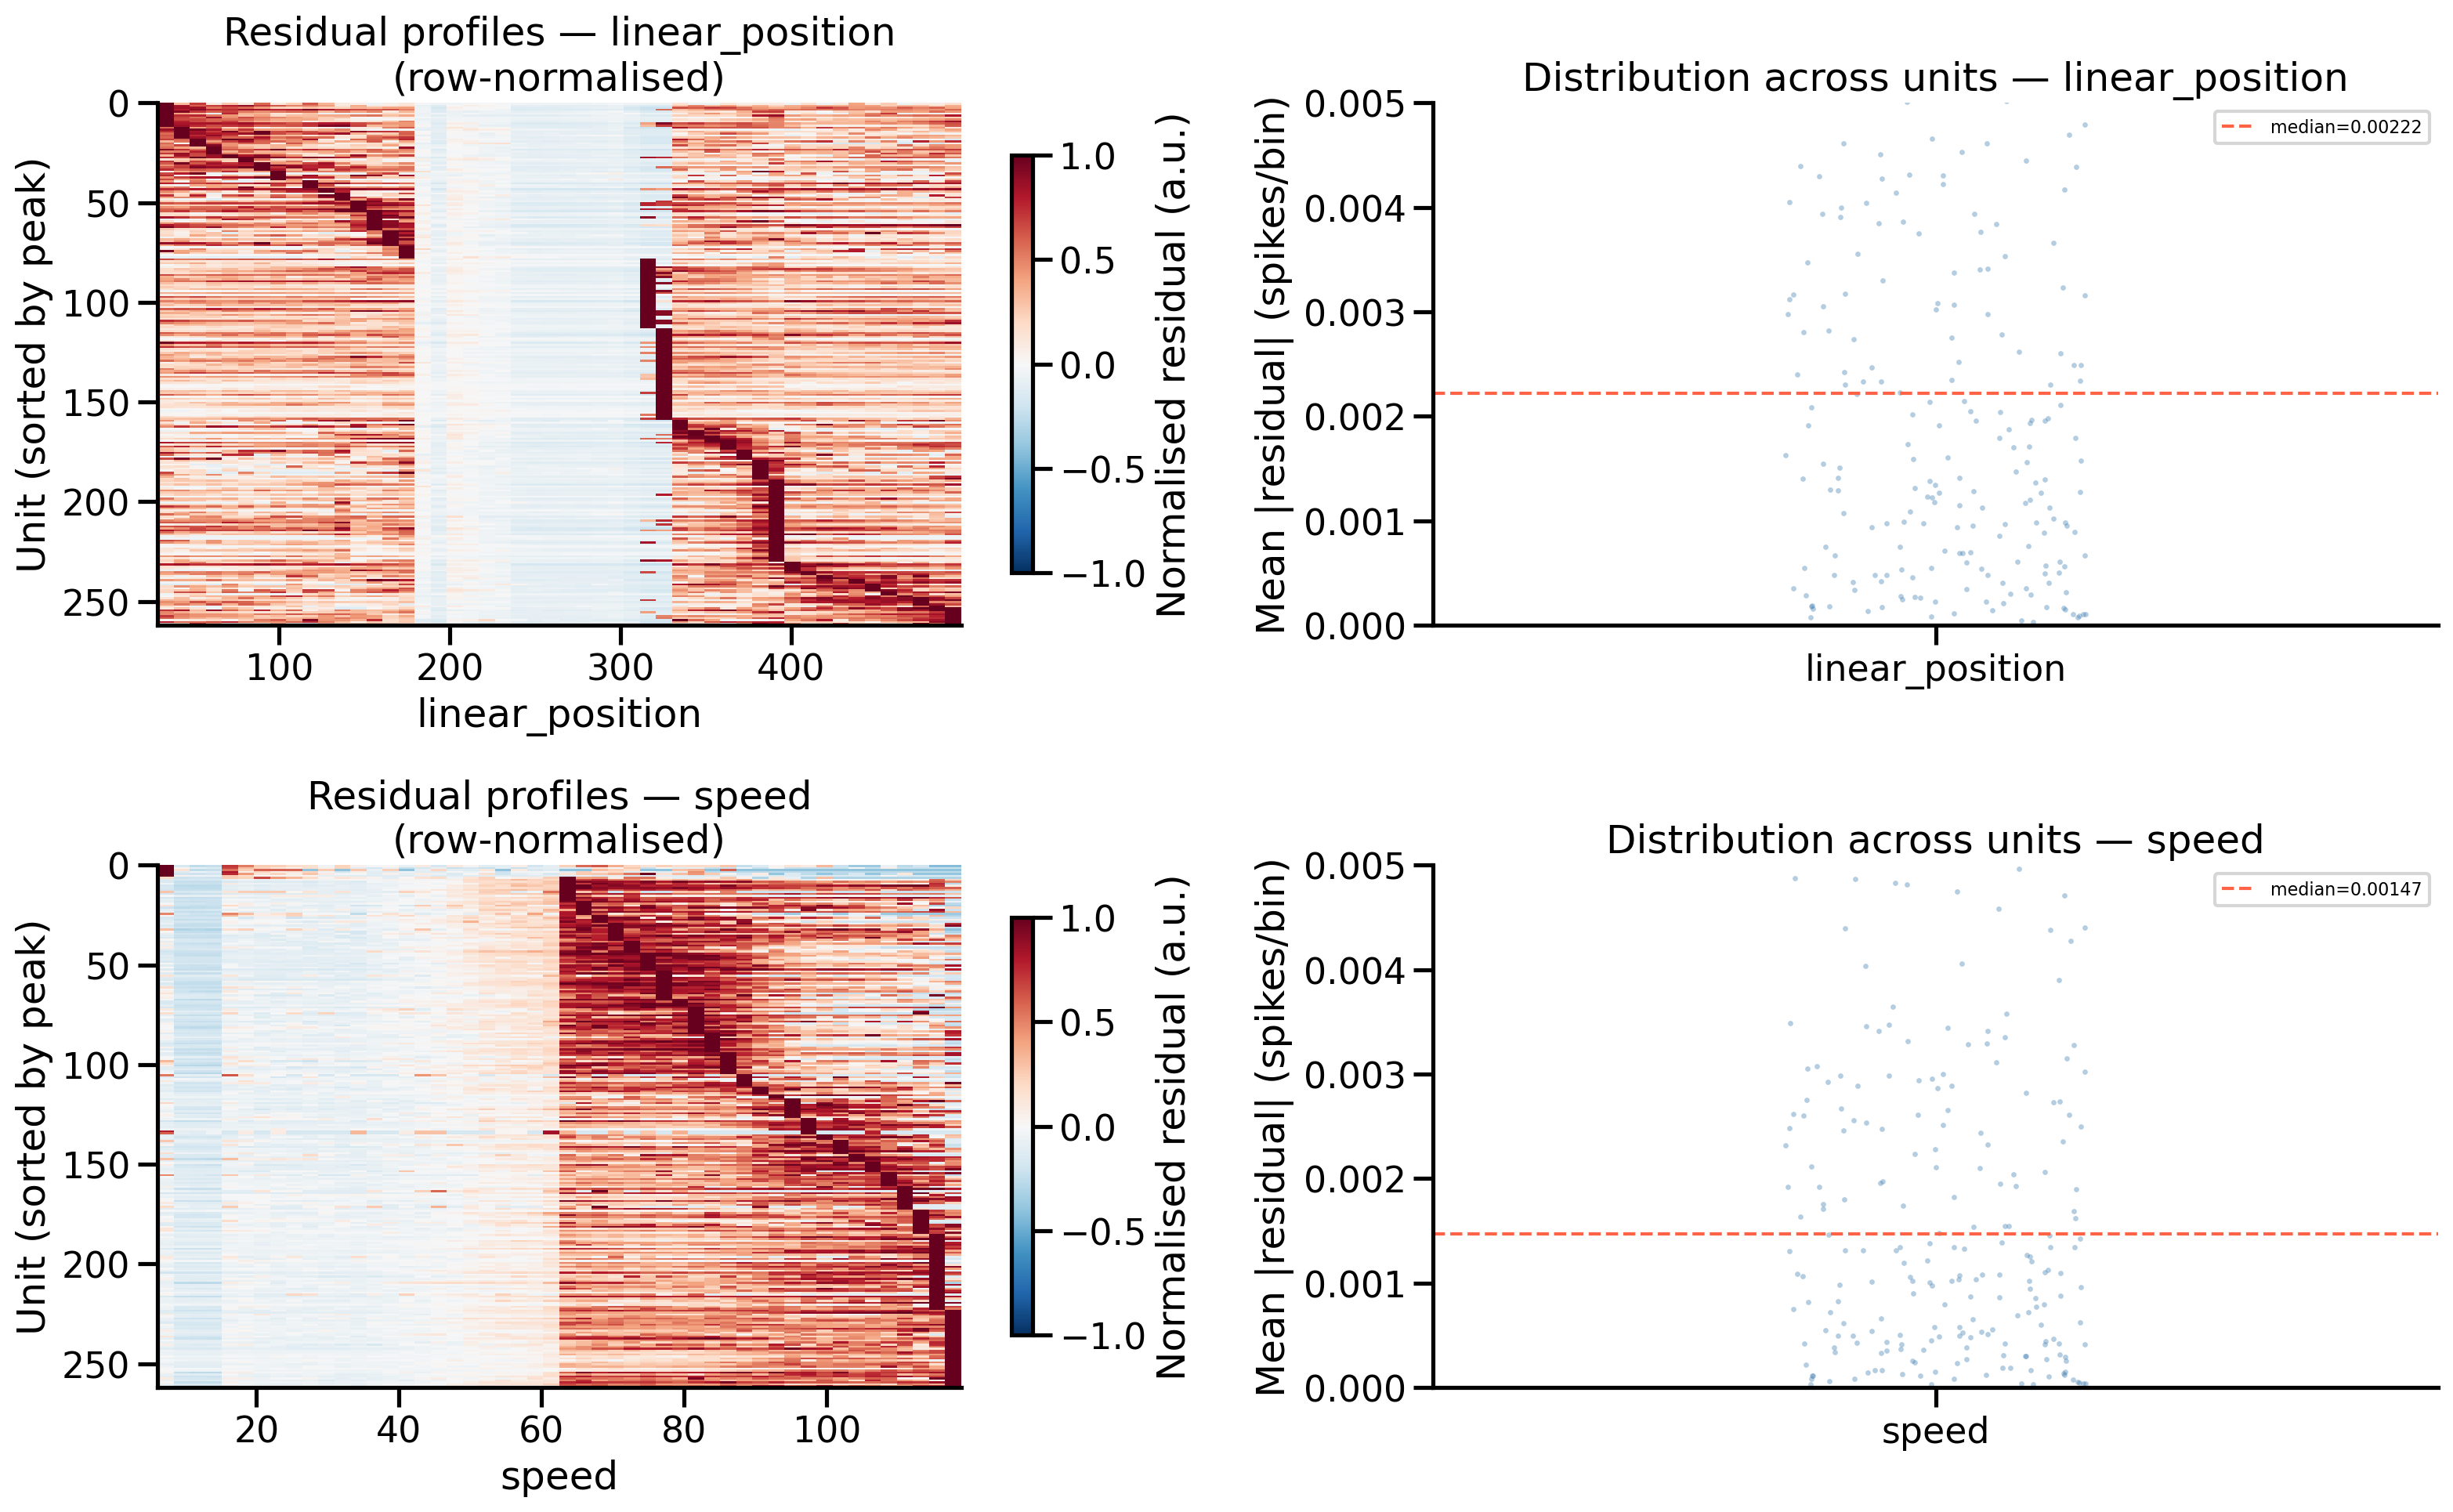

In [71]:
plot_residual_heterogeneity(prof_null)


### Null (outbound only)

#### Fit on one unit

In [16]:
unit_idx = 9
spk_cov_df = cov_df.copy(); spk_cov_df["spike_count"] = spike_counts_masked[unit_idx]
spk_cov_df_common = cov_df_common.copy(); spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]
choice_spk_cov_df = spk_cov_df[cov_df["trial_type"] == "outbound"].copy()

model_constant_out = smf.glm("spike_count ~ 1", 
                             data=spk_cov_df[spk_cov_df["trial_type"]=="outbound"], 
                             family=sm.families.Poisson())
results_constant_out = model_constant_out.fit()

print(results_constant_out.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               867583
Model:                            GLM   Df Residuals:                   867582
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4094.8
Date:                Sat, 14 Mar 2026   Deviance:                       7225.7
Time:                        13:47:16   Pearson chi2:                 8.67e+05
No. Iterations:                     9   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.4955      0.046   -164.560      0.0

In [17]:
# Interpret the coefficient
mean_count_per_bin = np.exp(results_constant_out.params["Intercept"])
mean_rate_hz = mean_count_per_bin / BIN_SIZE

print(f"β₀ = {results_constant_out.params['Intercept']:.4f}")
print(f"exp(β₀) = {mean_count_per_bin:.4f} spikes/bin")
print(f"Firing rate = {mean_rate_hz:.2f} Hz")
print(f'Observed mean = {spk_cov_df[spk_cov_df["trial_type"]=="outbound"]["spike_count"].mean():.4f} spikes/bin')

β₀ = -7.4955
exp(β₀) = 0.0006 spikes/bin
Firing rate = 0.28 Hz
Observed mean = 0.0006 spikes/bin


In [ ]:
# Diagnostics — null outbound
plot_diagnostics(
    results        = results_constant_out,
    spike_counts   = spike_counts_out_common[unit_idx],
    cov_df         = cov_df_out_common,
    covariate_cols = ["linear_position", "speed"],
)

In [91]:
formula = "spike_count ~ 1"

plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = formula,
    cov_df              = cov_df_out_common,
    spike_counts_masked = spike_counts_out_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [18]:
# null_model_out_all = fit_glm_all_units("spike_count ~ 1", cov_df_out_common, spike_counts_out_common, unit_ids)

In [19]:
# null_model_out_all["model"] = "null_out"
# null_model_out_all.to_csv(f"{base_dir}/analysis/null_model_out_all.csv")
# keep_default_na=False prevents pandas reading "null" string as NaN (fixed)
null_model_out_all = pd.read_csv(f"{base_dir}/analysis/null_model_out_all.csv", index_col=0,
                                  keep_default_na=False, na_values=[''])
null_model_out_all.head(2)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,56246.726118587,-28122.363059293,47171.043884753,1.000000000,816658.000000000,True,{'Intercept': -5.192073150454998},{'Intercept': 0.014839670194953783},47171.043884753,0.000000000,NaN,null_out
1,1,25383.999939308,-12690.999969654,21826.158822392,1.000000000,816658.000000000,True,{'Intercept': -6.128607038264865},{'Intercept': 0.023702272993155984},21826.158822392,0.000000000,NaN,null_out


In [62]:
diag_null_out = pd.read_csv(f"{base_dir}/analysis/diagnostics_null_model_out_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_null_model_out_all.npz", allow_pickle=True)
prof_null_out = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_null_out, covariate_cols=COVARIATE_COLS)

NameError: name 'COVARIATE_COLS' is not defined

In [61]:
plot_residual_profiles(prof_null_out, covariate_cols=COVARIATE_COLS)

NameError: name 'prof_null_out' is not defined

### Trial type

#### Fit on one unit

In [20]:
unit_idx = 14
spk_cov_df = cov_df.copy(); spk_cov_df["spike_count"] = spike_counts_masked[unit_idx]
spk_cov_df_common = cov_df_common.copy(); spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]
choice_spk_cov_df = spk_cov_df[cov_df["trial_type"] == "outbound"].copy()

model_trial_type = smf.glm("spike_count ~ trial_type", data=spk_cov_df, family=sm.families.Poisson())
results_trial_type = model_trial_type.fit()

print(results_trial_type.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:              1835243
Model:                            GLM   Df Residuals:                  1835241
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -34915.
Date:                Sat, 14 Mar 2026   Deviance:                       59670.
Time:                        13:47:20   Pearson chi2:                 1.83e+06
No. Iterations:                     8   Pseudo R-squ. (CS):          9.197e-05
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -5

In [21]:
plot_categorical_comparison(results_trial_type, "trial_type", spk_cov_df_common)


In [22]:
rate_inbound  = np.exp(results_trial_type.params["Intercept"]) / BIN_SIZE        # Hz
rate_outbound = np.exp(results_trial_type.params["Intercept"] + results_trial_type.params["trial_type[T.outbound]"]) / BIN_SIZE
ratio         = np.exp(results_trial_type.params["trial_type[T.outbound]"])      # outbound/inbound rate ratio

print("inbound rate: ", rate_inbound)
print("outbound rate: ", rate_outbound)
print("outbound/inbound: ", ratio)

inbound rate:  1.6214372816666964
outbound rate:  1.1192012752369913
outbound/inbound:  0.6902525850932386


In [ ]:
# Diagnostics — trial_type model
plot_diagnostics(
    results        = results_trial_type,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
    covariate_cols = ["linear_position", "speed"],
)

In [92]:
formula = "spike_count ~ trial_type"

plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit all units 

In [23]:
# trial_type_model_all = fit_glm_all_units("spike_count ~ trial_type", cov_df_common, spike_counts_common, unit_ids)

In [24]:
# trial_type_model_all.to_csv(f"{base_dir}/analysis/trial_type_model_all.csv")
trial_type_model_all = pd.read_csv(f"{base_dir}/analysis/trial_type_model_all.csv", index_col=0)
trial_type_model_all["model"] = "trial_type"

In [25]:
trial_type_model_all.head()

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,131583.887559961,-65789.943779981,109995.613447184,2.000000000,1756595.000000000,True,"{'Intercept': -5.010834263411056, 'trial_type[...","{'Intercept': 0.012633958975539225, 'trial_typ...",110082.814171105,1.000000000,NaN,trial_type
1,1,54610.689479532,-27303.344739766,46950.848362615,2.000000000,1756595.000000000,True,"{'Intercept': -6.127973058569825, 'trial_type[...","{'Intercept': 0.022086305064722443, 'trial_typ...",46950.848745556,1.000000000,NaN,trial_type
2,2,26787.700634476,-13391.850317238,23409.700634476,2.000000000,1756595.000000000,True,"{'Intercept': -7.089159110347969, 'trial_type[...","{'Intercept': 0.03571428571380185, 'trial_type...",23443.161855586,1.000000000,NaN,trial_type
3,3,79487.181752602,-39741.590876301,67602.113224407,2.000000000,1756595.000000000,True,"{'Intercept': -5.615587676249746, 'trial_type[...","{'Intercept': 0.01709464148535772, 'trial_type...",67641.725887742,1.000000000,NaN,trial_type
4,4,110046.662126007,-55021.331063003,92580.662126007,2.000000000,1756595.000000000,True,"{'Intercept': -5.241588506345702, 'trial_type[...","{'Intercept': 0.014179049201633688, 'trial_typ...",92622.859673762,1.000000000,NaN,trial_type


In [122]:
diag_trial_type = pd.read_csv(f"{base_dir}/analysis/diagnostics_trial_type_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_trial_type_model_all.npz", allow_pickle=True)
prof_trial_type = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_trial_type, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:948: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:957: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:964: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



In [123]:
plot_residual_profiles(prof_trial_type, covariate_cols=COVARIATE_COLS)

### Choice

#### Fit on one unit

In [26]:
unit_idx = 16
spk_cov_df = cov_df.copy(); spk_cov_df["spike_count"] = spike_counts_masked[unit_idx]
spk_cov_df_common = cov_df_common.copy(); spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]
choice_spk_cov_df = spk_cov_df[cov_df["trial_type"] == "outbound"].copy()

model_choice = smf.glm("spike_count ~ choice", data=choice_spk_cov_df, family=sm.families.Poisson())
results_choice = model_choice.fit()

print(results_choice.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               867583
Model:                            GLM   Df Residuals:                   867581
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4051.6
Date:                Sat, 14 Mar 2026   Deviance:                       7105.2
Time:                        13:47:21   Pearson chi2:                 8.67e+05
No. Iterations:                    10   Pseudo R-squ. (CS):          0.0003927
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -6.1380      0.066    -

In [126]:
plot_categorical_comparison(results_choice, "choice", choice_spk_cov_df)


In [28]:
rate_left  = np.exp(results_choice.params["Intercept"]) / BIN_SIZE        # Hz
rate_right = np.exp(results_choice.params["Intercept"] + results_choice.params["choice[T.right]"]) / BIN_SIZE
ratio         = np.exp(results_choice.params["choice[T.right]"])      # outbound/inbound rate ratio

print("left rate: ", rate_left)
print("right rate: ", rate_right)
print("right/left: ", ratio)

left rate:  1.0796670630200804
right rate:  0.17837048073637668
right/left:  0.1652087822679641


In [ ]:
# Diagnostics — choice model
# choice_spk_cov_df already contains the outbound spike counts for unit_idx
plot_diagnostics(
    results        = results_choice,
    spike_counts   = choice_spk_cov_df["spike_count"].values,
    cov_df         = choice_spk_cov_df,
    covariate_cols = ["linear_position", "speed"],
)

In [125]:
formula = "spike_count ~ choice"

plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = formula,
    cov_df              = cov_df_out_common,
    spike_counts_masked = spike_counts_out_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit for all units

In [29]:
# choice_model_all = fit_glm_all_units("spike_count ~ choice", cov_df_out_common, spike_counts_out_common, unit_ids)

In [30]:
# choice_model_all.to_csv(f"{base_dir}/analysis/choice_model_all.csv")
choice_model_all = pd.read_csv(f"{base_dir}/analysis/choice_model_all.csv", index_col=0)
choice_model_all["model"] = "choice"

In [31]:
choice_model_all.head()

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,49113.003489998,-24554.501744999,40035.321256165,2.000000000,816658.000000000,True,"{'Intercept': -3.517220133837597, 'choice[T.ri...","{'Intercept': 0.018248288941681203, 'choice[T....",47171.043884753,1.000000000,NaN,choice
1,1,21589.469989400,-10792.734994700,18029.628872483,2.000000000,816658.000000000,True,"{'Intercept': -4.3152469452174795, 'choice[T.r...","{'Intercept': 0.02719641337908737, 'choice[T.r...",21826.158822392,1.000000000,NaN,choice
2,2,11945.222854198,-5970.611427099,10135.222854198,2.000000000,816658.000000000,True,"{'Intercept': -4.942562062926476, 'choice[T.ri...","{'Intercept': 0.03721614637198732, 'choice[T.r...",12293.899149411,1.000000000,NaN,choice
3,3,31548.924988980,-15772.462494490,26503.697577702,2.000000000,816658.000000000,True,"{'Intercept': -4.2839375075651205, 'choice[T.r...","{'Intercept': 0.026773977610566102, 'choice[T....",29160.713401839,1.000000000,NaN,choice
4,4,38792.005071434,-19394.002535717,31274.005071434,2.000000000,816658.000000000,True,"{'Intercept': -3.507939324762412, 'choice[T.ri...","{'Intercept': 0.01816381340601528, 'choice[T.r...",40437.339664736,1.000000000,NaN,choice


In [124]:
diag_choice = pd.read_csv(f"{base_dir}/analysis/diagnostics_choice_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_choice_model_all.npz", allow_pickle=True)
prof_choice = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_choice, covariate_cols=COVARIATE_COLS)

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:948: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:957: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/media/labuser/NA_1_2025/spyglass/wilbur/notebooks/encoding_utils.py:964: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



In [ ]:
plot_residual_profiles(prof_choice, covariate_cols=COVARIATE_COLS)

### Speed (spline)

#### FIt on one unit


In [32]:
unit_idx = 16
spk_cov_df = cov_df.copy(); spk_cov_df["spike_count"] = spike_counts_masked[unit_idx]
spk_cov_df_common = cov_df_common.copy(); spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]
choice_spk_cov_df = spk_cov_df[cov_df["trial_type"] == "outbound"].copy()

from patsy import bs, cr

# speed_min_val, speed_max_val defined in common mask cell
bs_df = 4
model_speed_spline = smf.glm(f"spike_count ~ bs(speed_scaled, df={bs_df})",
                              data=spk_cov_df_common,
                              family=sm.families.Poisson())
results_speed_spline = model_speed_spline.fit()
print(results_speed_spline.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:              1756595
Model:                            GLM   Df Residuals:                  1756590
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8086.5
Date:                Sat, 14 Mar 2026   Deviance:                       14099.
Time:                        13:47:24   Pearson chi2:                 1.70e+06
No. Iterations:                    10   Pseudo R-squ. (CS):          0.0007517
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [33]:
plot_tuning_comparison(
    results_speed_spline,
    pd.DataFrame({"speed_scaled": np.linspace(0, 1, 200)}),
    "speed_scaled",
    "speed",
    spk_cov_df_common,
    min_val=speed_min_val,
    max_val=speed_max_val,
    xlabel="Speed (cm/s)",
)


In [34]:
speeds_of_interest = [10, 20, 30, 40, 60]
speeds_scaled = (np.array(speeds_of_interest) - speed_min_val) / (speed_max_val - speed_min_val)
rates = results_speed_spline.predict(pd.DataFrame({"speed_scaled": speeds_scaled})) / BIN_SIZE

print("Spline model — predicted rates:")
for s, r in zip(speeds_of_interest, rates):
    print(f"  speed={s:2f} cm/s → {r:.2f} Hz")

speed_range = np.linspace(speed_min_val, speed_max_val, 500)
speed_range_scaled = (speed_range - speed_min_val) / (speed_max_val - speed_min_val)
pred_curve = results_speed_spline.predict(pd.DataFrame({"speed_scaled": speed_range_scaled})) / BIN_SIZE
peak_speed = speed_range[np.argmax(pred_curve)]
print(f"\nPeak firing at: {peak_speed:.1f} cm/s ({pred_curve.max():.2f} Hz)")
print(f"Rate ratio high/low speed: {pred_curve.max() / pred_curve.min():.2f}x")

Spline model — predicted rates:
  speed=10.000000 cm/s → 0.04 Hz
  speed=20.000000 cm/s → 0.08 Hz
  speed=30.000000 cm/s → 0.16 Hz
  speed=40.000000 cm/s → 0.29 Hz
  speed=60.000000 cm/s → 0.68 Hz

Peak firing at: 109.6 cm/s (1.32 Hz)
Rate ratio high/low speed: 30.40x


In [35]:
fig, ax = plt.subplots(figsize=(7, 4))

speed_bins = np.linspace(speed_min_val, speed_max_val, 30)
bin_idx = np.digitize(spk_cov_df_common["speed"], speed_bins) - 1  # changed

obs_speed, obs_rate, obs_ci = [], [], []
for b in range(len(speed_bins) - 1):
    sel = bin_idx == b
    if sel.sum() > 50:
        counts = spk_cov_df_common.loc[sel, "spike_count"].values  # changed
        obs_speed.append(speed_bins[b:b+2].mean())
        obs_rate.append(counts.mean() / BIN_SIZE)
        obs_ci.append(1.96 * stats.sem(counts) / BIN_SIZE)

obs_speed, obs_rate, obs_ci = map(np.array, [obs_speed, obs_rate, obs_ci])
ax.errorbar(obs_speed, obs_rate, yerr=obs_ci,
            fmt="o", ms=4, color="grey", ecolor="lightgrey",
            elinewidth=1.5, capsize=3, label="observed ± 95% CI", zorder=3)

speed_range = np.linspace(speed_min_val, speed_max_val, 300)
speed_range_scaled = (speed_range - speed_min_val) / (speed_max_val - speed_min_val)
pred_rate = results_speed_spline.predict(pd.DataFrame({"speed_scaled": speed_range_scaled})) / BIN_SIZE

ax.plot(speed_range, pred_rate, color="steelblue", lw=2, label=f"spline fit (df={bs_df})")
ax.set_xlabel("speed (cm/s)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title(f"unit {unit_idx} — speed tuning")
ax.legend()
sns.despine()
plt.tight_layout()

In [ ]:
# Diagnostics — speed spline
plot_diagnostics(
    results        = results_speed_spline,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
    covariate_cols = ["linear_position", "speed"],
)

In [97]:
formula = "spike_count ~ bs(speed_scaled, df=4)"

plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [36]:
# speed_scaled already in cov_df_common (added in common mask cell)
# speed_spline_model_all = fit_glm_all_units(f"spike_count ~ bs(speed_scaled, df={bs_df})",
#                                             cov_df_common, spike_counts_common, unit_ids)

In [37]:
# speed_spline_model_all["model"] = "speed spline"
# speed_spline_model_all.to_csv(f"{base_dir}/analysis/speed_spline_model_all.csv")
speed_spline_model_all = pd.read_csv(f"{base_dir}/analysis/speed_spline_model_all.csv", index_col=0)
speed_spline_model_all.head(1)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,122885.260660869,-61437.630330435,101290.986548092,5.000000000,1756595.000000000,True,"{'Intercept': -5.013915239708803, 'bs(speed_sc...","{'Intercept': 0.07509759833182705, 'bs(speed_s...",110082.814171105,4.000000000,NaN,speed_spline


In [ ]:
diag_speed = pd.read_csv(f"{base_dir}/analysis/diagnostics_speed_spline_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_speed_spline_model_all.npz", allow_pickle=True)
prof_speed = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_speed, covariate_cols=COVARIATE_COLS)

In [ ]:
plot_residual_profiles(prof_speed, covariate_cols=COVARIATE_COLS)

### Linear position (spline)

#### Fit on one unit

In [38]:
unit_idx = 169
spk_cov_df = cov_df.copy(); spk_cov_df["spike_count"] = spike_counts_masked[unit_idx]
spk_cov_df_common = cov_df_common.copy(); spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]
choice_spk_cov_df = spk_cov_df[cov_df["trial_type"] == "outbound"].copy()

# pos_min_val, pos_max_val, pos_scaled defined in common mask cell
model_pos_spline = smf.glm("spike_count ~ bs(pos_scaled, df=8)",
                           data=spk_cov_df_common,
                           family=sm.families.Poisson())
results_pos_spline = model_pos_spline.fit()
print(results_pos_spline.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:              1756595
Model:                            GLM   Df Residuals:                  1756586
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11429.
Date:                Sat, 14 Mar 2026   Deviance:                       19761.
Time:                        13:47:28   Pearson chi2:                 1.77e+06
No. Iterations:                    10   Pseudo R-squ. (CS):           0.001147
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [39]:
_pos_run_cmp = trialized_position[trialized_position["zone"] == "run"][
    ["linear_position", "projected_x_position", "projected_y_position"]
].dropna().iloc[::5].copy()

plot_tuning_comparison(
    results_pos_spline,
    pd.DataFrame({"pos_scaled": np.linspace(0, 1, 200)}),
    "pos_scaled",
    "linear_position",
    spk_cov_df_common,
    min_val=pos_min_val,
    max_val=pos_max_val,
    xlabel="Position (cm)",
)
plot_wtrack_comparison(unit_idx, spk_cov_df_common,
                       results=results_pos_spline, pos_run=_pos_run_cmp)


In [40]:
pos_range = np.linspace(pos_min_val, pos_max_val, 500)
pos_range_scaled = (pos_range - pos_min_val) / (pos_max_val - pos_min_val)  # changed
pred_rate = results_pos_spline.predict(pd.DataFrame({"pos_scaled": pos_range_scaled})) / BIN_SIZE  # changed

peak_pos  = pos_range[np.argmax(pred_rate)]
peak_rate = pred_rate.max()
print(f"Peak firing position: {peak_pos:.1f} cm, rate: {peak_rate:.2f} Hz")

Peak firing position: 453.4 cm, rate: 3.26 Hz


In [41]:
fig, ax = plt.subplots()

pos_bins = np.linspace(pos_min_val, pos_max_val, 40)
bin_idx  = np.digitize(spk_cov_df["linear_position"].dropna(), pos_bins) - 1
pos_df   = spk_cov_df[spk_cov_df["linear_position"].notna()].copy()

obs_pos, obs_rate, obs_ci = [], [], []
for b in range(len(pos_bins) - 1):
    sel = bin_idx == b
    if sel.sum() > 50:
        counts = pos_df.iloc[np.where(sel)[0]]["spike_count"].values
        obs_pos.append(pos_bins[b:b+2].mean())
        obs_rate.append(counts.mean() / BIN_SIZE)
        obs_ci.append(1.96 * stats.sem(counts) / BIN_SIZE)

ax.errorbar(obs_pos, obs_rate, yerr=obs_ci,
            fmt="o", ms=4, color="grey", ecolor="lightgrey",
            elinewidth=1.5, capsize=3, label="observed ± 95% CI", zorder=3)

ax.plot(pos_range, pred_rate, color="steelblue", lw=2, label="spline fit (df=8)")
ax.axvline(peak_pos, color="red", lw=1, linestyle="--", label=f"peak @ {peak_pos:.0f} cm")
ax.set_xlabel("linear position (cm)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title(f"unit {unit_idx} — position tuning")
ax.legend()
sns.despine()
plt.tight_layout()

In [42]:
graph = sgpl.TrackGraph & {"track_graph_name": "Wtrack_wilbur20210512"}

# Use original camera frames (not 2ms-interpolated bins) — avoids diagonal artifacts
# at trial transitions where np.interp crosses track space (changed)
pos_run = trialized_position[trialized_position["zone"] == "run"][
    ["linear_position", "projected_x_position", "projected_y_position"]
].dropna().iloc[::5]

pos_run = pos_run.copy()
pos_run["pos_scaled"] = (pos_run["linear_position"] - pos_min_val) / (pos_max_val - pos_min_val)
pos_run = pos_run[(pos_run["pos_scaled"] >= 0) & (pos_run["pos_scaled"] <= 1)]

track_rate_hz = results_pos_spline.predict(pos_run[["pos_scaled"]]) / BIN_SIZE

fig, (ax_curve, ax_track) = plt.subplots(1, 2, figsize=(14, 5))

ax_curve.plot(pos_range, pred_rate, color="steelblue", lw=2)
ax_curve.errorbar(obs_pos, obs_rate, yerr=obs_ci,
            fmt="o", ms=4, color="grey", ecolor="lightgrey",
            elinewidth=1.5, capsize=3, label="observed ± 95% CI", zorder=3)
ax_curve.set_xlabel("linear position (cm)")
ax_curve.set_ylabel("firing rate (Hz)")
ax_curve.set_title(f"unit {unit_idx} — position tuning")

graph.plot_track_graph(ax=ax_track, draw_edge_labels=False)
for ln in ax_track.lines:
    ln.set_color("lightgrey")

sc = ax_track.scatter(pos_run["projected_x_position"], pos_run["projected_y_position"],
                      c=track_rate_hz, cmap="hot_r", s=4, zorder=3,
                      vmin=track_rate_hz.min(), vmax=track_rate_hz.max())
plt.colorbar(sc, ax=ax_track, label="firing rate (Hz)")
ax_track.set_xlabel("x position (cm)")
ax_track.set_ylabel("y position (cm)")
ax_track.set_title(f"unit {unit_idx} — rate on track")

sns.despine()
plt.tight_layout()

In [ ]:
# Diagnostics — position spline
plot_diagnostics(
    results        = results_pos_spline,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
    covariate_cols = ["linear_position", "speed"],
)

In [100]:
formula = "spike_count ~ bs(pos_scaled, df=8)"

plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [43]:
# pos_scaled already in cov_df_common (added in common mask cell)
# pos_spline_model_all = fit_glm_all_units("spike_count ~ bs(pos_scaled, df=8)",
#                                           cov_df_common, spike_counts_common, unit_ids)

In [44]:
# pos_spline_model_all["model"] = "pos_spline"
# pos_spline_model_all.to_csv(f"{base_dir}/analysis/pos_spline_model_all.csv")
pos_spline_model_all = pd.read_csv(f"{base_dir}/analysis/pos_spline_model_all.csv", index_col = 0)
pos_spline_model_all.head(2)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,116512.411290878,-58247.205645439,94910.137178100,9.000000000,1756595.000000000,True,"{'Intercept': -3.5939448356082364, 'bs(pos_sca...","{'Intercept': 0.06155158105423916, 'bs(pos_sca...",110082.814171105,8.000000000,NaN,pos_spline
1,1,51476.254485278,-25729.127242639,43802.413368361,9.000000000,1756595.000000000,True,"{'Intercept': -5.246723861965011, 'bs(pos_scal...","{'Intercept': 0.1273808876721047, 'bs(pos_scal...",46950.848745556,8.000000000,NaN,pos_spline


In [ ]:
diag_pos = pd.read_csv(f"{base_dir}/analysis/diagnostics_pos_spline_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_pos_spline_model_all.npz", allow_pickle=True)
prof_pos = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_pos, covariate_cols=COVARIATE_COLS)

In [ ]:
plot_residual_profiles(prof_pos, covariate_cols=COVARIATE_COLS)

### Trial progress (spline)

#### Fit on one unit

In [45]:
unit_idx = 169
spk_cov_df = cov_df.copy(); spk_cov_df["spike_count"] = spike_counts_masked[unit_idx]
spk_cov_df_common = cov_df_common.copy(); spk_cov_df_common["spike_count"] = spike_counts_common[unit_idx]
choice_spk_cov_df = spk_cov_df[cov_df["trial_type"] == "outbound"].copy()

tp_df = 6

# trial_progress is already [0, 1] — no scaling needed
print(f"trial_progress NaN in cov_df_common: {spk_cov_df_common['trial_progress'].isna().sum()}")

model_tp_spline = smf.glm(
    f"spike_count ~ cr(trial_progress, df={tp_df}, constraints='center')",
    data=spk_cov_df_common,
    family=sm.families.Poisson()
)
results_tp_spline = model_tp_spline.fit()
print(results_tp_spline.summary())

trial_progress NaN in cov_df_common: 0
                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:              1756595
Model:                            GLM   Df Residuals:                  1756588
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11804.
Date:                Sat, 14 Mar 2026   Deviance:                       20513.
Time:                        13:47:31   Pearson chi2:                 1.55e+06
No. Iterations:                     9   Pseudo R-squ. (CS):          0.0007200
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

In [46]:
plot_tuning_comparison(
    results_tp_spline,
    pd.DataFrame({"trial_progress": np.linspace(0, 1, 200)}),
    "trial_progress",
    "trial_progress",
    spk_cov_df_common,
    xlabel="Trial progress",
)


In [47]:
tp_min = spk_cov_df_common["trial_progress"].min()
tp_max = spk_cov_df_common["trial_progress"].max()
tp_range = np.linspace(tp_min, tp_max, 300)
pred_tp = results_tp_spline.predict(pd.DataFrame({"trial_progress": tp_range})) / BIN_SIZE

peak_tp = tp_range[np.argmax(pred_tp)]
print(f"Peak firing at trial_progress = {peak_tp:.2f}, rate = {pred_tp.max():.2f} Hz")

# Observed binned rate
tp_bins = np.linspace(tp_min, tp_max, 25)
tp_bin_idx = np.digitize(spk_cov_df_common["trial_progress"], tp_bins) - 1
obs_tp, obs_tp_rate, obs_tp_ci = [], [], []
for b in range(len(tp_bins) - 1):
    sel = tp_bin_idx == b
    if sel.sum() > 50:
        counts = spk_cov_df_common.loc[sel, "spike_count"].values
        obs_tp.append(tp_bins[b:b+2].mean())
        obs_tp_rate.append(counts.mean() / BIN_SIZE)
        obs_tp_ci.append(1.96 * stats.sem(counts) / BIN_SIZE)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(obs_tp, obs_tp_rate, yerr=obs_tp_ci,
            fmt="o", ms=4, color="grey", ecolor="lightgrey",
            elinewidth=1.5, capsize=3, label="observed ± 95% CI", zorder=3)
ax.plot(tp_range, pred_tp, color="steelblue", lw=2, label=f"spline fit (df={tp_df})")
ax.axvline(peak_tp, color="red", lw=1, linestyle="--", label=f"peak @ {peak_tp:.2f}")
ax.set_xlabel("trial progress (0 = start, 1 = end)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title(f"unit {unit_idx} — trial progress tuning")
ax.legend()
sns.despine()
plt.tight_layout()

Peak firing at trial_progress = 0.78, rate = 1.03 Hz


In [ ]:
# Diagnostics — trial progress spline
plot_diagnostics(
    results        = results_tp_spline,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
    covariate_cols = ["linear_position", "speed"],
)

In [101]:
formula = f"spike_count ~ cr(trial_progress, df={tp_df}, constraints='center')"

plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [48]:
# tp_df defined above
# tp_progress_spline_model_all = fit_glm_all_units(f"spike_count ~ cr(trial_progress, df={tp_df}, constraints='center')",
#                                                   cov_df_common, spike_counts_common, unit_ids)

In [49]:
# tp_progress_spline_model_all["model"] = "trial_progress_spline"
# tp_progress_spline_model_all.to_csv(f"{base_dir}/analysis/trial_progress_spline_model_all.csv")
trial_progress_spline_model_all = pd.read_csv(
    f"{base_dir}/analysis/trial_progress_spline_model_all.csv", index_col=0
)
trial_progress_spline_model_all.head(2)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,125111.039538532,-62548.519769266,103512.765425755,7.000000000,1756595.000000000,True,"{'Intercept': -5.935167341177781, ""cr(trial_pr...","{'Intercept': 0.05217593190562265, ""cr(trial_p...",110082.814171105,6.000000000,NaN,trial_progress_spline
1,1,51926.193294323,-25956.096647162,44256.352177407,7.000000000,1756595.000000000,True,"{'Intercept': -7.192475542188085, ""cr(trial_pr...","{'Intercept': 0.1273311312072992, ""cr(trial_pr...",46950.848745556,6.000000000,NaN,trial_progress_spline


In [ ]:
diag_tp = pd.read_csv(f"{base_dir}/analysis/diagnostics_trial_progress_spline_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_trial_progress_spline_model_all.npz", allow_pickle=True)
prof_tp = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_tp, covariate_cols=COVARIATE_COLS)

In [ ]:
plot_residual_profiles(prof_tp, covariate_cols=COVARIATE_COLS)

## Combined models

### Full model (trial type, position , speed)

#### Fit on one unit

In [50]:
full_model_formula = "spike_count ~ trial_type + bs(pos_scaled, df = 8) + bs(speed_scaled, df = 4)"


In [51]:
model_full_pos = smf.glm(
    full_model_formula,
    data=spk_cov_df_common,
    family=sm.families.Poisson()
)
results_full_pos = model_full_pos.fit(maxiter = 200)
print(results_full_pos.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:              1756595
Model:                            GLM   Df Residuals:                  1756581
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10865.
Date:                Sat, 14 Mar 2026   Deviance:                       18634.
Time:                        13:47:38   Pearson chi2:                 1.29e+06
No. Iterations:                    10   Pseudo R-squ. (CS):           0.001788
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
# Diagnostics — full model
plot_diagnostics(
    results        = results_full_pos,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
    covariate_cols = ["linear_position", "speed"],
)

In [102]:
plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = full_model_formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [52]:
# full_model_all = fit_glm_all_units(full_model_formula, cov_df_common, spike_counts_common, unit_ids)

In [53]:
# full_model_all["model"] = "full_model"
# full_model_all.to_csv(f"{base_dir}/analysis/full_model_all.csv")
full_model_all = pd.read_csv(f"{base_dir}/analysis/full_model_all.csv", index_col=0)
full_model_all.head(2)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,114114.147088039,-57043.073544019,92501.872975261,14.000000000,1756595.000000000,True,"{'Intercept': -3.629033564726252, 'trial_type[...","{'Intercept': 0.0928687142925612, 'trial_type[...",110082.814171105,13.000000000,NaN,full_model
1,1,48964.875886940,-24468.437943470,41281.034770024,14.000000000,1756595.000000000,True,"{'Intercept': -4.79925523623829, 'trial_type[T...","{'Intercept': 0.1689481665382055, 'trial_type[...",46950.848745556,13.000000000,NaN,full_model


In [ ]:
diag_full = pd.read_csv(f"{base_dir}/analysis/diagnostics_full_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_full_model_all.npz", allow_pickle=True)
prof_full = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_full, covariate_cols=COVARIATE_COLS)

In [ ]:
plot_residual_profiles(prof_full, covariate_cols=COVARIATE_COLS)

### Temporal full model (trial type, progress, speed)

Replaces position with trial_progress — same structure as full model but asks whether mPFC tracks *when within a trial* rather than *where on the track*. Compare AIC directly to `full_model` (same dataset, same n_obs).

#### Fit on one unit

In [54]:
temporal_model_formula = (
    f"spike_count ~ trial_type  + cr(trial_progress, df={tp_df}, constraints='center') + bs(speed_scaled, df=4)"
)

model_temporal = smf.glm(temporal_model_formula, data=spk_cov_df_common, family=sm.families.Poisson())
results_temporal = model_temporal.fit(disp=False)
print(results_temporal.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:              1756595
Model:                            GLM   Df Residuals:                  1756583
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10878.
Date:                Sat, 14 Mar 2026   Deviance:                       18659.
Time:                        13:47:44   Pearson chi2:                 1.64e+06
No. Iterations:                    10   Pseudo R-squ. (CS):           0.001774
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [ ]:
# Diagnostics — temporal model
plot_diagnostics(
    results        = results_temporal,
    spike_counts   = spike_counts_common[unit_idx],
    cov_df         = cov_df_common,
    covariate_cols = ["linear_position", "speed"],
)

In [ ]:
plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = temporal_model_formula,
    cov_df              = cov_df_common,
    spike_counts_masked = spike_counts_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [55]:
# temporal_model_all = fit_glm_all_units(temporal_model_formula, cov_df_common, spike_counts_common, unit_ids)

In [56]:
# temporal_model_all["model"] = "temporal_model"
# temporal_model_all.to_csv(f"{base_dir}/analysis/temporal_model_all.csv")
temporal_model_all = pd.read_csv(f"{base_dir}/analysis/temporal_model_all.csv", index_col=0)
temporal_model_all.head(2)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,118032.990517666,-59004.495258833,96424.716404889,12.000000000,1756595.000000000,True,"{'Intercept': -3.4491169200348617, 'trial_type...","{'Intercept': 0.07673825433941116, 'trial_type...",110082.814171105,11.000000000,NaN,temporal_model
1,1,49719.999530268,-24847.999765134,42040.158413352,12.000000000,1756595.000000000,True,"{'Intercept': -4.504202408649432, 'trial_type[...","{'Intercept': 0.1508563395616019, 'trial_type[...",46950.848745556,11.000000000,NaN,temporal_model


In [ ]:
diag_temporal = pd.read_csv(f"{base_dir}/analysis/diagnostics_temporal_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_temporal_model_all.npz", allow_pickle=True)
prof_temporal = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_temporal, covariate_cols=COVARIATE_COLS)

In [ ]:
plot_residual_profiles(prof_temporal, covariate_cols=COVARIATE_COLS)

### Choice full model (choice, position, speed) : outbound only

#### Fit on one unit

In [57]:
spk_cov_df_out_common = cov_df_out_common.copy()
spk_cov_df_out_common["spike_count"] = spike_counts_out_common[unit_idx]

choice_full_formula = "spike_count ~ choice + bs(pos_scaled, df=8) + bs(speed_scaled, df=4)"
model_choice_full = smf.glm(choice_full_formula, data=spk_cov_df_out_common, family=sm.families.Poisson())
results_choice_full = model_choice_full.fit(disp=False)
print(results_choice_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               816658
Model:                            GLM   Df Residuals:                   816644
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4187.5
Date:                Sat, 14 Mar 2026   Deviance:                       7175.1
Time:                        13:47:47   Pearson chi2:                 4.82e+05
No. Iterations:                    11   Pseudo R-squ. (CS):           0.001816
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
# Diagnostics — choice full model
plot_diagnostics(
    results        = results_choice_full,
    spike_counts   = spike_counts_out_common[unit_idx],
    cov_df         = cov_df_out_common,
    covariate_cols = ["linear_position", "speed"],
)

In [ ]:
plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = choice_full_formula,
    cov_df              = cov_df_out_common,
    spike_counts_masked = spike_counts_out_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [58]:
# choice_full_model_all = fit_glm_all_units(choice_full_formula, cov_df_out_common, spike_counts_out_common, unit_ids)
# choice_full_model_all["model"] = "choice_full_model"
# choice_full_model_all.to_csv(f"{base_dir}/analysis/choice_full_model_all.csv")

choice_full_model_all = pd.read_csv(f"{base_dir}/analysis/choice_full_model_all.csv", index_col = 0)
choice_full_model_all.head(2)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,47828.394038888,-23900.197019444,38726.711805054,14.000000000,816658.000000000,True,"{'Intercept': -4.933091191360118, 'choice[T.ri...","{'Intercept': 0.14575140129742745, 'choice[T.r...",47171.043884753,13.000000000,NaN,choice_full_model
1,1,21024.686445064,-10498.343222532,17440.845328148,14.000000000,816658.000000000,True,"{'Intercept': -6.762634952051057, 'choice[T.ri...","{'Intercept': 0.2948870383226812, 'choice[T.ri...",21826.158822392,13.000000000,NaN,choice_full_model


In [ ]:
diag_choice_full = pd.read_csv(f"{base_dir}/analysis/diagnostics_choice_full_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_choice_full_model_all.npz", allow_pickle=True)
prof_choice_full = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_choice_full, covariate_cols=COVARIATE_COLS)

In [ ]:
plot_residual_profiles(prof_choice_full, covariate_cols=COVARIATE_COLS)

### Choice temporal model (choice, trial progress, speed) — outbound only

#### Fit on one unit

In [60]:
choice_temporal_formula = (
    f"spike_count ~ choice"
    f" + cr(trial_progress, df=6, constraints='center')"
    f" + bs(speed_scaled, df=4)"
)
model_choice_temporal = smf.glm(choice_temporal_formula, data=spk_cov_df_out_common, family=sm.families.Poisson())
results_choice_temporal = model_choice_temporal.fit(disp=False)
print(results_choice_temporal.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            spike_count   No. Observations:               816658
Model:                            GLM   Df Residuals:                   816646
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4357.1
Date:                Sat, 14 Mar 2026   Deviance:                       7514.2
Time:                        13:49:07   Pearson chi2:                 5.62e+05
No. Iterations:                    11   Pseudo R-squ. (CS):           0.001401
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [ ]:
# Diagnostics — choice temporal
plot_diagnostics(
    results        = results_choice_temporal,
    spike_counts   = spike_counts_out_common[unit_idx],
    cov_df         = cov_df_out_common,
    covariate_cols = ["linear_position", "speed"],
)

In [ ]:
plot_diagnostics_batch(
    unit_list           = [12, 47, 103, 211, 58],
    formula             = choice_temporal_formula,
    cov_df              = cov_df_out_common,
    spike_counts_masked = spike_counts_out_common,
    unit_ids            = unit_ids,
    covariate_cols      = ["linear_position", "speed"],
)

#### Fit on all units

In [61]:
# choice_temporal_model_all = fit_glm_all_units(choice_temporal_formula, cov_df_out_common, spike_counts_out_common, unit_ids)
# choice_temporal_model_all["model"] = "choice_temporal_model"
# choice_temporal_model_all.to_csv(f"{base_dir}/analysis/choice_temporal_model_all.csv")

choice_temporal_model_all = pd.read_csv(f"{base_dir}/analysis/choice_temporal_model_all.csv", index_col = 0)
choice_temporal_model_all.head(2)

,unit,aic,llf,deviance,n_params,n_obs,converged,coef,bse,deviance_null,df_model,error,model
0,0,47811.700952203,-23893.850476102,38714.018718370,12.000000000,816658.000000000,True,"{'Intercept': -3.3959970850534575, 'choice[T.r...","{'Intercept': 0.09150621238917037, 'choice[T.r...",47171.043884753,11.000000000,NaN,choice_temporal_model
1,1,21209.571579213,-10592.785789606,17629.730462296,12.000000000,816658.000000000,True,"{'Intercept': -4.5688531926736164, 'choice[T.r...","{'Intercept': 0.16339802872606968, 'choice[T.r...",21826.158822392,11.000000000,NaN,choice_temporal_model


In [ ]:
diag_choice_temporal = pd.read_csv(f"{base_dir}/analysis/diagnostics_choice_temporal_model_all.csv", index_col=0)
_raw = np.load(f"{base_dir}/analysis/residual_profiles_choice_temporal_model_all.npz", allow_pickle=True)
prof_choice_temporal = {k: _raw[k] for k in _raw.files}
plot_diagnostics_population(diag_choice_temporal, covariate_cols=COVARIATE_COLS)

In [ ]:
plot_residual_profiles(prof_choice_temporal, covariate_cols=COVARIATE_COLS)

## Model comparison

### Single-variable

In [62]:
from scipy.stats import chi2

# Load all model CSVs
model_files = {
    "null":                    (f"{base_dir}/analysis/null_model_all.csv",                    dict(keep_default_na=False, na_values=[""])),
    "null_out":                (f"{base_dir}/analysis/null_model_out_all.csv",                dict(keep_default_na=False, na_values=[""])),
    "trial_type":              (f"{base_dir}/analysis/trial_type_model_all.csv",              {}),
    "choice":                  (f"{base_dir}/analysis/choice_model_all.csv",                  {}),
    "speed":                   (f"{base_dir}/analysis/speed_model_all.csv",                   {}),
    "speed_spline":            (f"{base_dir}/analysis/speed_spline_model_all.csv",            {}),
    "pos_spline":              (f"{base_dir}/analysis/pos_spline_model_all.csv",              {}),
    "trial_progress_spline":   (f"{base_dir}/analysis/trial_progress_spline_model_all.csv",  {}),
    "temporal_model_all":      (f"{base_dir}/analysis/temporal_model_all.csv",               {}),
    "full_model_all":          (f"{base_dir}/analysis/full_model_all.csv",                   {}),
    "choice_full_model_all":   (f"{base_dir}/analysis/choice_full_model_all.csv",                   {}),
    "choice_temporal_model_all":   (f"{base_dir}/analysis/choice_temporal_model_all.csv",                   {})
    
}

models = {}
for name, (path, kwargs) in model_files.items():
    df = pd.read_csv(path, index_col=0, **kwargs)
    df["model"] = name
    models[name] = df.set_index("unit")

# Null baseline per model — must match the dataset the model was fit on
null_for = {
    "trial_type":            "null",
    "speed":                 "null",
    "speed_spline":          "null",
    "pos_spline":            "null",
    "trial_progress_spline": "null",
    "choice":                "null_out",
    "temporal_model_all":    "null",
    "full_model_all":        "null",
    "choice_full_model_all": "null_out",
    "choice_temporal_model_all": "null_out"
}

rows = []
for model_name, null_name in null_for.items():
    m   = models[model_name]
    nul = models[null_name]

    for uid in m.index:
        row      = m.loc[uid]
        null_row = nul.loc[uid]

        lrt_stat = 2 * (row["llf"] - null_row["llf"])
        lrt_df   = int(row["df_model"]) if pd.notna(row["df_model"]) else 0
        lrt_pval = (1 - chi2.cdf(lrt_stat, lrt_df)) if lrt_df > 0 else np.nan

        rows.append(dict(
            unit        = uid,
            model       = model_name,
            aic         = row["aic"],
            llf         = row["llf"],
            n_params    = row["n_params"],
            n_obs       = row["n_obs"],
            converged   = row["converged"],
            delta_aic   = row["aic"] - null_row["aic"],
            lrt_stat    = lrt_stat,
            lrt_df      = lrt_df,
            lrt_pval    = lrt_pval,
            tuned       = bool(lrt_pval < 0.05) if not np.isnan(lrt_pval) else False,
        ))

comparison = pd.DataFrame(rows)

summary = comparison.groupby("model").agg(
    mean_dAIC  = ("delta_aic", "mean"),
    median_dAIC= ("delta_aic", "median"),
    n_tuned    = ("tuned",     "sum"),
    frac_tuned = ("tuned",     "mean"),
    n_converged= ("converged", "sum"),
).round(3)
print(summary)

                                mean_dAIC     median_dAIC  n_tuned  \
model                                                                
choice                    -1312.531000000  -571.002000000      252   
choice_full_model_all     -2986.436000000 -1694.728000000      259   
choice_temporal_model_all -2441.118000000 -1317.243000000      259   
full_model_all            -5767.983000000 -3391.540000000      262   
pos_spline                -3523.824000000 -1921.845000000      261   
speed                     -3061.827000000 -1593.043000000      257   
speed_spline              -3592.272000000 -1922.189000000      262   
temporal_model_all        -4747.166000000 -2796.546000000      260   
trial_progress_spline     -2641.916000000 -1540.833000000      260   
trial_type                  -55.532000000   -15.324000000      191   

                           frac_tuned  n_converged  
model                                               
choice                    0.958000000          262  


In [63]:
# Pivot to wide AIC table — enables direct pairwise model comparison
aic_wide = comparison.pivot(index="unit", columns="model", values="aic")

# Add null baselines (same common dataset, so directly comparable)
aic_wide["null"]     = models["null"]["aic"]
aic_wide["null_out"] = models["null_out"]["aic"]

# Best single-variable model per unit (all-trials models only)
all_trials_models = ["trial_type", "speed", "speed_spline", "pos_spline", "trial_progress_spline", "temporal_model_all", "full_model_all"]
aic_wide["best_model"] = aic_wide[all_trials_models].idxmin(axis=1)
print("Best model counts (all units):")
print(aic_wide["best_model"].value_counts())

# LRT: speed_linear vs speed_spline (nested — spline adds 3 df)
llf_wide = comparison.pivot(index="unit", columns="model", values="llf")
lrt_speed = 2 * (llf_wide["speed_spline"] - llf_wide["speed"])
lrt_speed_pval = lrt_speed.apply(lambda x: 1 - chi2.cdf(x, df=3))  # Δdf = 5-2 = 3
n_nonlinear = (lrt_speed_pval < 0.05).sum()
print(f"\nSpeed: nonlinear > linear in {n_nonlinear}/{len(lrt_speed_pval)} units (LRT p<0.05)")

Best model counts (all units):
best_model
full_model_all        241
temporal_model_all     21
Name: count, dtype: int64

Speed: nonlinear > linear in 258/263 units (LRT p<0.05)


/tmp/ipykernel_3825042/304535331.py:10: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  aic_wide["best_model"] = aic_wide[all_trials_models].idxmin(axis=1)


In [64]:
# ── Q1: what fraction of units are significantly tuned to each variable? ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

frac = summary["frac_tuned"].sort_values()
frac.plot.barh(ax=axes[0], color="steelblue")
axes[0].axvline(0.05, color="red", lw=1, ls="--", label="chance (α=0.05)")
axes[0].set_xlabel("fraction of units (LRT p < 0.05)")
axes[0].set_title("Fraction tuned per variable")
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# ── Q2: are different units tuned to different variables? ──────────────────────
# Pivot to unit × model binary matrix
tuned_wide = comparison.pivot(index="unit", columns="model", values="tuned").astype(int)

# Sort rows: units tuned to more variables go to the top
row_order = tuned_wide.sum(axis=1).sort_values().index
tuned_sorted = tuned_wide.loc[row_order]

axes[1].imshow(tuned_sorted.values, aspect="auto", cmap="Blues",
               interpolation="nearest", vmin=0, vmax=1)
axes[1].set_xticks(range(len(tuned_wide.columns)))
axes[1].set_xticklabels(tuned_wide.columns, rotation=40, ha="right", fontsize=9)
axes[1].set_ylabel("unit (sorted by n tuned variables)")
axes[1].set_xlabel("model")
axes[1].set_title("Tuning profile per unit")

plt.tight_layout()

In [65]:
# which model has the highest mean delta-AIC?
model_cols = ["trial_type", "speed", "speed_spline", "pos_spline", "trial_progress_spline"]
delta_aic = aic_wide[model_cols].subtract(aic_wide["null"], axis = 0)
print(delta_aic.mean(axis=0))
print("model with max delta aic: ", min(delta_aic.mean(axis = 0)))

model
trial_type                -55.532004209
speed                   -3061.826646431
speed_spline            -3592.271583448
pos_spline              -3523.823842328
trial_progress_spline   -2641.916287258
dtype: float64
model with max delta aic:  -3592.271583447503


### Drop-one & LRT (combined models)

In [66]:
drop_one_specs = make_drop_one_specs(
    cov_df_common, spike_counts_common,
    cov_df_out_common, spike_counts_out_common,
    base_dir
)

In [67]:
# ── Fit all drop-one suites ───────────────────────────────────────────────────
# Re-run this cell to refit; check_if_exists=True skips already-saved CSVs
for model_name in drop_one_specs:
    run_drop_one_suite(drop_one_specs, model_name, base_dir, unit_ids)


Running drop-one suite: temporal_model_all(3 fits)
    Skipping trial_type - file exists
    Skipping cr(trial_progress, df = 6, constraints = 'center') - file exists
    Skipping bs(speed_scaled, df = 4) - file exists

Running drop-one suite: full_model_all(3 fits)
    Skipping trial_type - file exists
    Skipping bs(pos_scaled, df = 8) - file exists
    Skipping bs(speed_scaled, df = 4) - file exists

Running drop-one suite: choice_full_model_all(3 fits)
    Skipping choice - file exists
    Skipping bs(pos_scaled, df = 8) - file exists
    Skipping bs(speed_scaled, df = 4) - file exists

Running drop-one suite: choice_temporal_model_all(3 fits)
    Skipping choice - file exists
    Skipping cr(trial_progress, df = 6, constraints = 'center') - file exists
    Skipping bs(speed_scaled, df = 4) - file exists


In [68]:
# ── Compute LRT for all models and concatenate ────────────────────────────────
# Run this cell independently once CSVs exist — no refitting needed
lrt_frames = [compute_drop_one_lrt(model_name, base_dir, drop_one_specs) for model_name in drop_one_specs]
drop_one_results = pd.concat(lrt_frames, ignore_index=True)

print(drop_one_results.shape)


  [temporal_model_all drop=trial_type] skipped 32 units (non-converged)
  [temporal_model_all drop=cr(trial_progress, df = 6, constraints = 'center')] skipped 29 units (non-converged)
  [temporal_model_all drop=bs(speed_scaled, df = 4)] skipped 32 units (non-converged)
  [full_model_all drop=trial_type] skipped 8 units (non-converged)
  [full_model_all drop=bs(pos_scaled, df = 8)] skipped 8 units (non-converged)
  [full_model_all drop=bs(speed_scaled, df = 4)] skipped 8 units (non-converged)
  [choice_full_model_all drop=choice] skipped 18 units (non-converged)
  [choice_full_model_all drop=bs(pos_scaled, df = 8)] skipped 18 units (non-converged)
  [choice_full_model_all drop=bs(speed_scaled, df = 4)] skipped 20 units (non-converged)
  [choice_temporal_model_all drop=choice] skipped 44 units (non-converged)
  [choice_temporal_model_all drop=cr(trial_progress, df = 6, constraints = 'center')] skipped 41 units (non-converged)
  [choice_temporal_model_all drop=bs(speed_scaled, df = 4)] sk

In [69]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_drop = (
    drop_one_results
    .groupby(["model", "dropped_term"])
    .agg(
        n_units          = ("unit",        "count"),
        n_significant    = ("significant", "sum"),
        frac_significant = ("significant", "mean"),
        mean_delta_aic   = ("delta_aic",   "mean"),
        median_delta_aic = ("delta_aic",   "median"),
    )
    .round(3)
)
print(summary_drop.to_string())

# ── Short labels for plotting ──────────────────────────────────────────────────
term_labels = {
    "trial_type": "trial_type",
    "choice":     "choice",
    "bs(pos_scaled, df = 8)":                             "position",
    "bs(speed_scaled, df = 4)":                           "speed",
    "cr(trial_progress, df = 6, constraints = 'center')": "trial_progress",
}
plot_df = drop_one_results.copy()
plot_df["term_label"] = plot_df["dropped_term"].map(term_labels).fillna(plot_df["dropped_term"])

summary_plot = (
    plot_df.groupby(["model", "term_label"])
    .agg(frac_significant=("significant", "mean"), mean_delta_aic=("delta_aic", "mean"))
    .round(3)
)

# ── Figure: fraction significant + mean delta AIC ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
summary_plot["frac_significant"].unstack("term_label").plot.barh(ax=ax)
ax.axvline(0.05, color="red", lw=1, ls="--", label="α=0.05")
ax.set_xlabel("fraction of units (LRT p < 0.05)")
ax.set_title("Unique contribution: fraction significant")
ax.legend(title="dropped term", fontsize=8, loc="lower right")
sns.despine(ax=ax)

ax = axes[1]
summary_plot["mean_delta_aic"].unstack("term_label").plot.barh(ax=ax)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("mean ΔAIC (full − reduced)\nnegative = full model better")
ax.set_title("Unique contribution: effect size (AIC)")
ax.legend(title="dropped term", fontsize=8, loc="lower right")
sns.despine(ax=ax)

plt.tight_layout()

# ── Figure: per-unit delta AIC distributions ──────────────────────────────────
g = sns.FacetGrid(plot_df, col="model", col_wrap=2, height=4, sharey=False, sharex=False)
g.map_dataframe(
    sns.boxplot, x="delta_aic", y="term_label",
    color="steelblue", width=0.5, flierprops=dict(marker=".", ms=3)
)
g.map(plt.axvline, x=0, color="red", lw=1, ls="--")
g.set_axis_labels("ΔAIC (full − reduced)", "dropped term")
g.set_titles("{col_name}")
sns.despine()
plt.tight_layout()

                                                                              n_units  n_significant  frac_significant  mean_delta_aic  median_delta_aic
model                     dropped_term                                                                                                                  
choice_full_model_all     bs(pos_scaled, df = 8)                                  245            244       0.996000000 -1144.577000000    -658.705000000
                          bs(speed_scaled, df = 4)                                243            229       0.942000000  -422.434000000    -171.439000000
                          choice                                                  245            223       0.910000000  -307.567000000    -119.808000000
choice_temporal_model_all bs(speed_scaled, df = 4)                                219            216       0.986000000  -528.781000000    -339.275000000
                          choice                                                  

### Statistical summary

In [70]:
# FDR correction — adds 'significant_fdr' column
drop_one_results = apply_fdr_correction(drop_one_results)


In [71]:
# Pairwise comparison — run for each combined model
pw_full     = pairwise_term_comparison(drop_one_results, 'full_model_all')
pw_temporal = pairwise_term_comparison(drop_one_results, 'temporal_model_all')

print('Full model pairwise q-values:')
print(pw_full.round(3).to_string())


Full model pairwise q-values:
                          bs(pos_scaled, df = 8)  bs(speed_scaled, df = 4)  trial_type
bs(pos_scaled, df = 8)                       NaN               0.633000000 0.000000000
bs(speed_scaled, df = 4)             0.633000000                       NaN 0.000000000
trial_type                           0.000000000               0.000000000         NaN


In [72]:
plot_drop_one_summary(drop_one_results, pairwise_pvals=pw_full,
                      heatmap_model='full_model_all')


### Partial dependence — full model

position · speed · trial_type; others held at median/mode

In [73]:
med_pos_scaled   = spk_cov_df_common['pos_scaled'].median()
med_speed_scaled = spk_cov_df_common['speed_scaled'].median()
mode_trial_type  = spk_cov_df_common['trial_type'].mode()[0]

var_specs_full = [
    dict(sweep_col='pos_scaled',   actual_col='linear_position',
         xlabel='Position (cm)',    results_single=results_pos_spline,
         fixed={'speed_scaled': med_speed_scaled, 'trial_type': mode_trial_type},
         min_val=pos_min_val, max_val=pos_max_val),
    dict(sweep_col='speed_scaled', actual_col='speed',
         xlabel='Speed (cm/s)',     results_single=results_speed_spline,
         fixed={'pos_scaled': med_pos_scaled, 'trial_type': mode_trial_type},
         min_val=speed_min_val, max_val=speed_max_val),
    dict(sweep_col='trial_type',   actual_col='trial_type',
         xlabel='Trial type',       results_single=results_trial_type,
         fixed={'pos_scaled': med_pos_scaled, 'speed_scaled': med_speed_scaled},
         categorical=True),
]

plot_partial_dependence_grid(results_full_pos, var_specs_full, spk_cov_df_common,
                              title=f'Full model — unit {unit_idx}')


### Partial dependence — temporal model

trial_progress · speed · trial_type; others held at median/mode

In [74]:
med_tp           = spk_cov_df_common['trial_progress'].median()
# med_speed_scaled and mode_trial_type reuse values from full model cell above

var_specs_temporal = [
    dict(sweep_col='trial_progress', actual_col='trial_progress',
         xlabel='Trial progress',     results_single=results_tp_spline,
         fixed={'speed_scaled': med_speed_scaled, 'trial_type': mode_trial_type}),
    dict(sweep_col='speed_scaled',   actual_col='speed',
         xlabel='Speed (cm/s)',       results_single=results_speed_spline,
         fixed={'trial_progress': med_tp, 'trial_type': mode_trial_type},
         min_val=speed_min_val, max_val=speed_max_val),
    dict(sweep_col='trial_type',     actual_col='trial_type',
         xlabel='Trial type',         results_single=results_trial_type,
         fixed={'trial_progress': med_tp, 'speed_scaled': med_speed_scaled},
         categorical=True),
]

plot_partial_dependence_grid(results_temporal, var_specs_temporal, spk_cov_df_common,
                              title=f'Temporal model — unit {unit_idx}')


## Visualization

### Place field maps (position spline)

### Place field maps from pos_spline

In [75]:
import ast
from patsy import dmatrix

# ── shared prediction infrastructure (run once) ───────────────────────────────
pos_pred_vals = np.linspace(pos_min_val, pos_max_val, 300)
pos_pred_scaled = (pos_pred_vals - pos_min_val) / (pos_max_val - pos_min_val)

# Fit reference unit to capture patsy's design_info (knot placement)
_ref = cov_df_common[["pos_scaled"]].copy()
_ref["spike_count"] = spike_counts_common[0]
_ref_fit = smf.glm("spike_count ~ bs(pos_scaled, df=8)", data=_ref, family=sm.families.Poisson()).fit()

X_pred = np.array(dmatrix(_ref_fit.model.data.design_info,
                           pd.DataFrame({"pos_scaled": pos_pred_scaled})))

# Parse stored coefficients — eval() handles bare `nan` tokens that ast.literal_eval rejects
_NAN_NS = {"nan": float("nan")}

def _rate_curve(row):
    if not isinstance(row["coef"], str):
        return np.full(len(pos_pred_vals), np.nan)
    coefs = np.array(list(eval(row["coef"], _NAN_NS).values()))
    if np.any(np.isnan(coefs)):
        return np.full(len(pos_pred_vals), np.nan)
    return np.exp(X_pred @ coefs) / BIN_SIZE

rate_matrix = np.vstack([_rate_curve(r) for _, r in pos_spline_model_all.iterrows()])

# Peak position — NaN for units whose fit failed (all-NaN row)
valid_units = ~np.isnan(rate_matrix).all(axis=1)
peak_pos_cm = np.full(len(rate_matrix), np.nan)
peak_pos_cm[valid_units] = pos_pred_vals[np.argmax(rate_matrix[valid_units], axis=1)]

# Track projection data (downsampled) — used by all track plots
pos_run = trialized_position[trialized_position["zone"] == "run"][
    ["linear_position", "projected_x_position", "projected_y_position"]
].dropna().iloc[::5].copy()
pos_run["pos_scaled"] = (pos_run["linear_position"] - pos_min_val) / (pos_max_val - pos_min_val)
pos_run = pos_run[(pos_run["pos_scaled"] >= 0) & (pos_run["pos_scaled"] <= 1)]

n_failed = (~valid_units).sum()
print(f"rate_matrix: {rate_matrix.shape}  ({n_failed} units failed/skipped)")
print(f"peak positions range: {np.nanmin(peak_pos_cm):.0f} – {np.nanmax(peak_pos_cm):.0f} cm")

# ── initialise plot state for encoding_utils plot functions ───────────────────
set_plot_state(rate_matrix, pos_pred_vals, pos_run, peak_pos_cm)

rate_matrix: (263, 300)  (2 units failed/skipped)
peak positions range: 24 – 504 cm


#### 1. Single unit

In [76]:
# plot_place_field → encoding_utils.py
selected_unit = 12
plot_place_field(selected_unit)

#### 2. Grid of selected units

In [77]:
# plot_place_field_grid → encoding_utils.py
grid_units = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_place_field_grid(grid_units, ncols=4)

#### 3. Population summary (all units)

In [ ]:
# ── population heatmap: valid units only, sorted by peak position ─────────────
valid_idx = np.where(valid_units)[0]
sort_order = valid_idx[np.argsort(peak_pos_cm[valid_idx])]

rate_sorted = rate_matrix[sort_order]
rate_norm = (rate_sorted - rate_sorted.min(axis=1, keepdims=True)) / \
            (rate_sorted.max(axis=1, keepdims=True) - rate_sorted.min(axis=1, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(rate_norm, aspect="auto", origin="lower", cmap="hot_r",
                    extent=[pos_pred_vals[0], pos_pred_vals[-1], 0, len(sort_order)])
plt.colorbar(im, ax=axes[0], label="normalised rate")
axes[0].set_xlabel("linear position (cm)")
axes[0].set_ylabel(f"unit (sorted by peak,  n={len(sort_order)})")
axes[0].set_title("Population place fields")

axes[1].hist(peak_pos_cm[valid_idx], bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("peak position (cm)")
axes[1].set_ylabel("unit count")
axes[1].set_title("Distribution of place field peaks")
sns.despine(ax=axes[1])

plt.tight_layout()